In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score




In [3]:
rawdf = pd.read_excel(r"C:\Users\USER\Downloads\ExcelR PRojects\P592-Customer Segmentatiom\marketing_campaign.xlsx") 

In [4]:
df = rawdf.copy()

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


Id: Unique identifier for each individual in the dataset.

Year_Birth: The birth year of the individual.

Education: The highest level of education attained by the individual.

Marital_Status: The marital status of the individual.

Income: The annual income of the individual.

Kidhome: The number of young children in the household.

Teenhome: The number of teenagers in the household.

Dt_Customer: The date when the customer was first enrolled or became a part of the company's database.

Recency: The number of days since the last purchase or interaction.

MntWines: The amount spent on wines.

MntFruits: The amount spent on fruits.

MntMeatProducts: The amount spent on meat products.

MntFishProducts: The amount spent on fish products.

MntSweetProducts: The amount spent on sweet products.

MntGoldProds: The amount spent on gold products.

NumDealsPurchases: The number of purchases made with a discount or as part of a deal.

NumWebPurchases: The number of purchases made through the company's website.

NumCatalogPurchases: The number of purchases made through catalogs.

NumStorePurchases: The number of purchases made in physical stores.

NumWebVisitsMonth: The number of visits to the company's website in a month.

AcceptedCmp3: Binary indicator (1 or 0) whether the individual accepted the third marketing campaign.

AcceptedCmp4: Binary indicator (1 or 0) whether the individual accepted the fourth marketing campaign.

AcceptedCmp5: Binary indicator (1 or 0) whether the individual accepted the fifth marketing campaign.

AcceptedCmp1: Binary indicator (1 or 0) whether the individual accepted the first marketing campaign.

AcceptedCmp2: Binary indicator (1 or 0) whether the individual accepted the second marketing campaign.

Complain: Binary indicator (1 or 0) whether the individual has made a complaint.

Z_CostContact: A constant cost associated with contacting a customer.

Z_Revenue: A constant revenue associated with a successful campaign response.

Response: Binary indicator (1 or 0) whether the individual responded to the marketing campaign.

In [7]:
df.shape

(2240, 29)

In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [10]:
# DATA CLEANING 

In [11]:
# Checking for Duplicates 
df.duplicated().sum()

0

In [12]:
# Checking for missing  values
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [13]:
# Income column has 24 missing values 
# We can drop them or 
# df.dropna(inplace = True)


# we can fill them with median(filled with median due to presence of outliers )
# Fill missing Income with median

df['Income'].fillna(df['Income'].median(), inplace=True)

In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2240.0,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Year_Birth,2240.0,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
Income,2240.0,52237.975446,1730.0,35538.75,51381.5,68289.75,666666.0,25037.955891
Kidhome,2240.0,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Teenhome,2240.0,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,2013-07-10 10:01:42.857142784,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
Recency,2240.0,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MntWines,2240.0,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393
MntFruits,2240.0,26.302232,0.0,1.0,8.0,33.0,199.0,39.773434
MntMeatProducts,2240.0,166.95,0.0,16.0,67.0,232.0,1725.0,225.715373


In [15]:
df.sample(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1455,4399,1969,Graduation,Together,68695.0,0,0,2014-06-25,3,458,...,2,0,0,0,0,0,0,3,11,0
537,6931,1967,Graduation,Divorced,76982.0,0,0,2014-02-15,19,464,...,4,0,0,1,0,0,0,3,11,1
1512,9451,1965,Graduation,Married,73538.0,0,1,2012-11-25,92,811,...,7,0,0,0,0,0,0,3,11,0
1327,839,1975,PhD,Married,45503.0,1,0,2013-09-25,54,97,...,5,0,0,0,0,0,0,3,11,0
2143,9727,1957,Graduation,Married,23539.0,0,0,2014-02-28,13,4,...,6,0,0,0,0,0,0,3,11,0
74,1050,1952,Graduation,Married,28332.0,0,0,2014-04-30,58,14,...,2,0,0,0,0,0,0,3,11,0
1217,8876,1963,PhD,Together,33629.0,1,1,2012-08-08,49,132,...,9,0,0,0,0,0,0,3,11,0
1053,5740,1970,2n Cycle,Divorced,25959.0,1,1,2013-02-14,1,4,...,6,0,0,0,0,0,0,3,11,1
1794,9905,1952,Graduation,Together,34074.0,1,1,2013-07-13,69,135,...,6,1,0,0,0,0,0,3,11,0
271,5726,1983,Master,Single,31788.0,1,0,2014-03-20,15,16,...,5,0,0,0,0,0,1,3,11,0


In [16]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [17]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [18]:
# FEATURE ENGINEERING

In [19]:
# Creating new column named 'AGE'
df['Age'] = 2025 - df['Year_Birth']
df['Age']

0       68
1       71
2       60
3       41
4       44
        ..
2235    58
2236    79
2237    44
2238    69
2239    71
Name: Age, Length: 2240, dtype: int64

In [20]:
# creating total children 
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Total_Children']

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2240, dtype: int64

In [21]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='object')

In [22]:
# creating spending for adding all the spending
spending = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

df['Spending'] = df[spending].sum(axis=1)
df['Spending']

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Spending, Length: 2240, dtype: int64

In [23]:
# number of days since the customer joined
df['Customer_Since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days
df['Customer_Since']


0       4812
1       4262
2       4461
3       4288
4       4310
        ... 
2235    4530
2236    4168
2237    4304
2238    4305
2239    4771
Name: Customer_Since, Length: 2240, dtype: int64

In [24]:
df['TotalPurchases'] = (
    df['NumDealsPurchases'] + df['NumWebPurchases'] +
    df['NumCatalogPurchases'] + df['NumStorePurchases']
)
df['TotalPurchases']

0       25
1        6
2       21
3        8
4       19
        ..
2235    18
2236    22
2237    19
2238    23
2239    11
Name: TotalPurchases, Length: 2240, dtype: int64

In [25]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Spending', 'Customer_Since',
       'TotalPurchases'],
      dtype='object')

In [26]:
# EDA Visulazation

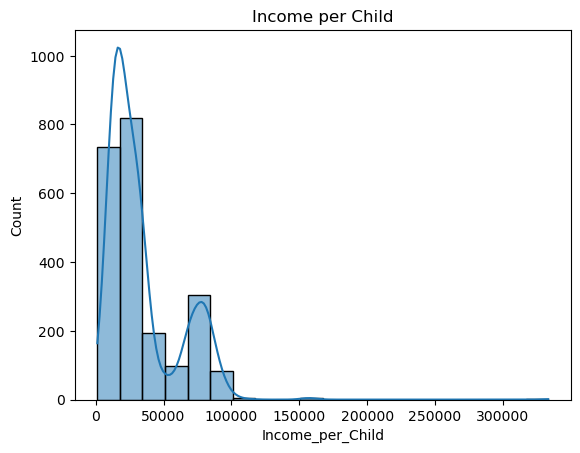

In [27]:
# Income per Child
df['Income_per_Child'] = df['Income'] / (df['Total_Children'] + 1)
sns.histplot(df['Income_per_Child'], kde=True, bins=20)
plt.title('Income per Child')
plt.show()

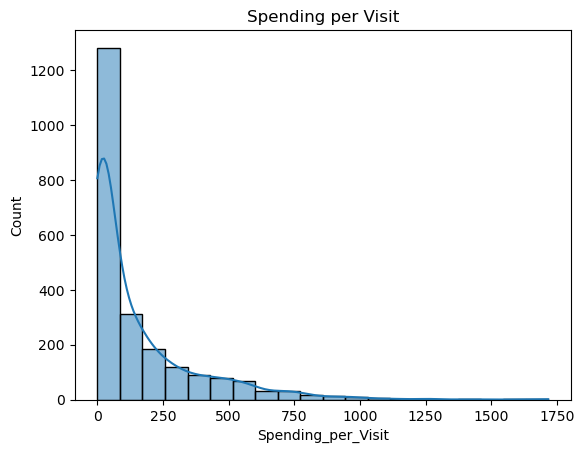

In [28]:
# Spending per Visit
df['Spending_per_Visit'] = df['Spending'] / (df['NumWebVisitsMonth'] + 1)
sns.histplot(df['Spending_per_Visit'], kde=True, bins=20)
plt.title('Spending per Visit')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

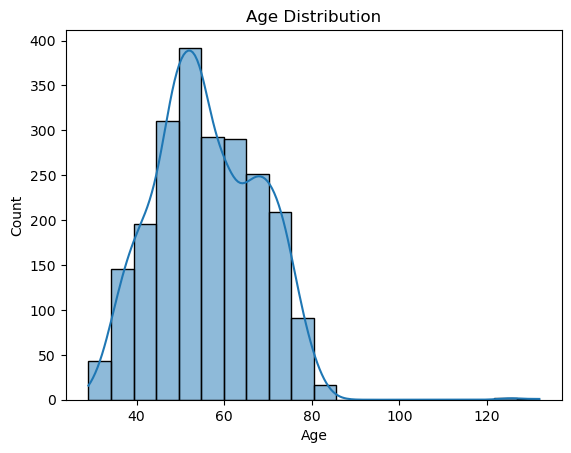

In [29]:
# Age Distribution 
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Age Distribution')
plt.show

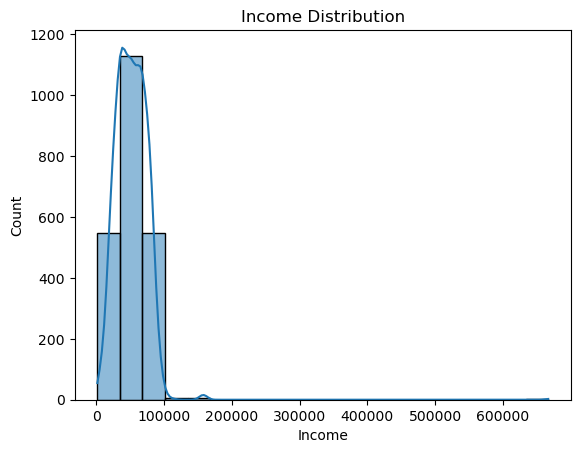

In [30]:
# Histrogram of Income Distribution
sns.histplot(df['Income'], kde=True, bins=20)
plt.title('Income Distribution')
plt.show()

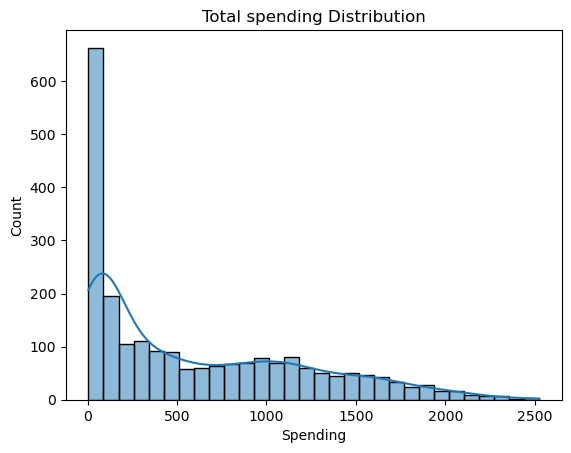

In [31]:
# Total spending Distribution
sns.histplot(df['Spending'], kde=True, bins=30)
plt.title('Total spending Distribution')
plt.show()

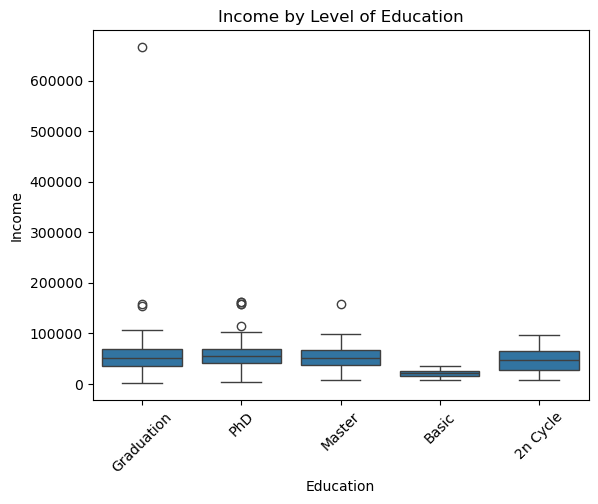

In [32]:
#  Boxplot Income by Level of Education
sns.boxplot(x = 'Education', y = 'Income', data=df )
plt.xticks(rotation=45)
plt.title('Income by Level of Education')
plt.show()

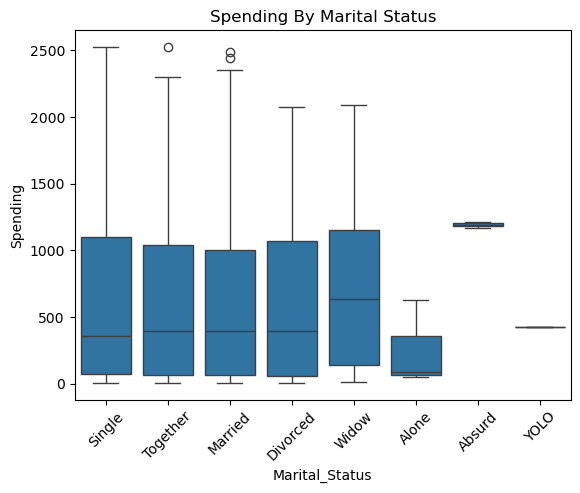

In [33]:
# Boxplot of Spending By Marital Status
sns.boxplot(x = 'Marital_Status', y = 'Spending', data=df)
plt.xticks(rotation=45)
plt.title('Spending By Marital Status')
plt.show()

In [34]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Spending', 'Customer_Since', 'TotalPurchases',
       'Income_per_Child', 'Spending_per_Visit'],
      dtype='object')

In [35]:
# Correlation 
corr = df[['Income','Age','Recency','Spending', 'NumStorePurchases','NumWebPurchases']].corr()
corr

,Income,Age,Recency,Spending,NumStorePurchases,NumWebPurchases
Income,1.000000,0.160899,-0.004061,0.664775,0.526600,0.380554
Age,0.160899,1.000000,0.019871,0.111306,0.128272,0.145040
Recency,-0.004061,0.019871,1.000000,0.020433,0.000799,-0.010726
Spending,0.664775,0.111306,0.020433,1.000000,0.674669,0.519837
NumStorePurchases,0.526600,0.128272,0.000799,0.674669,1.000000,0.502713
NumWebPurchases,0.380554,0.145040,-0.010726,0.519837,0.502713,1.000000


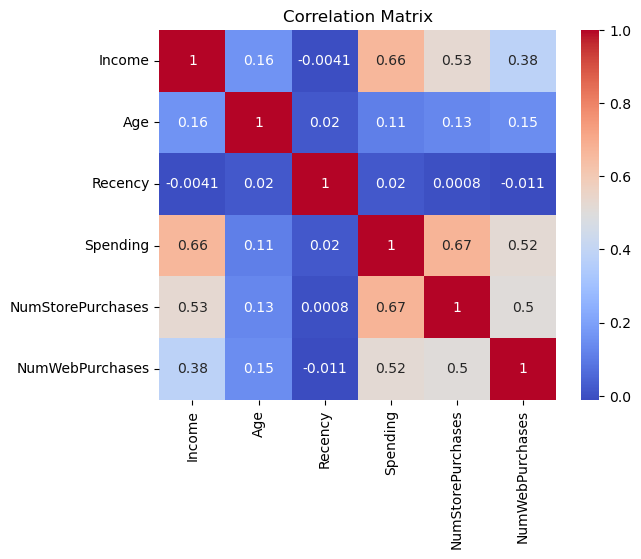

In [36]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

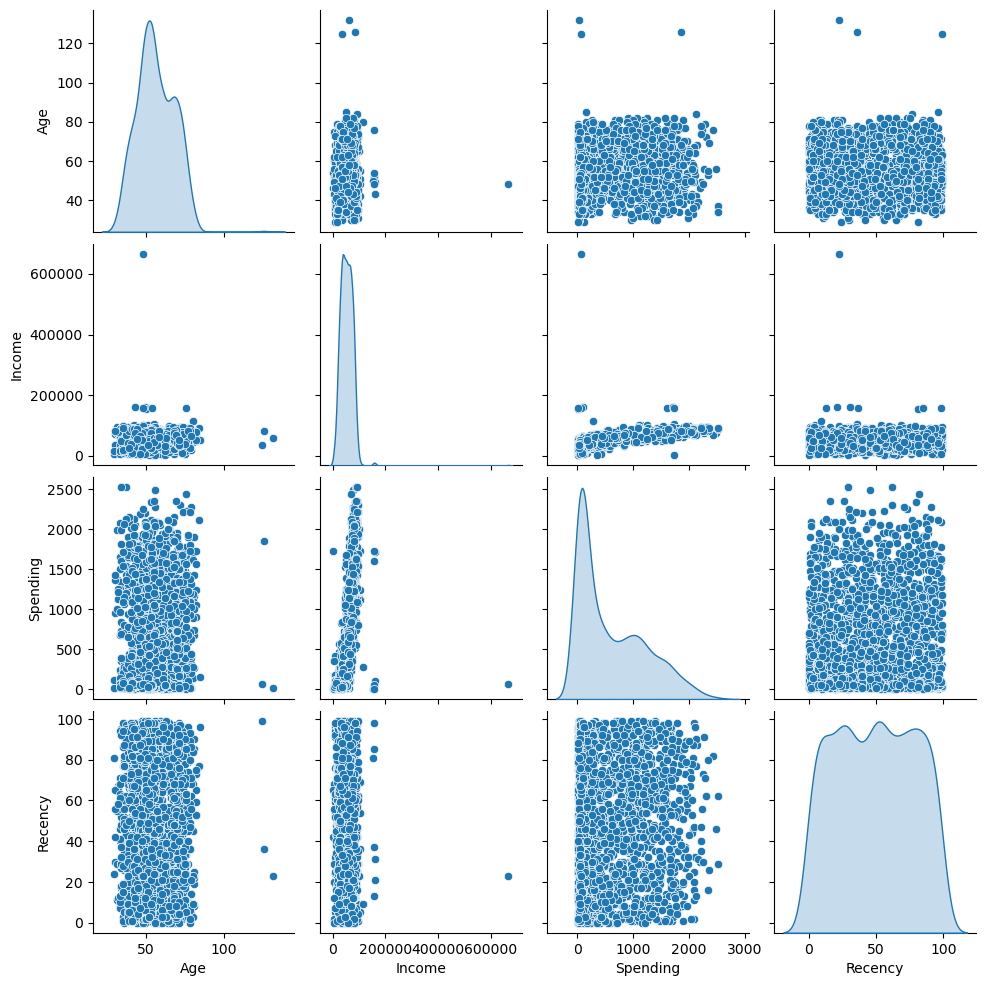

In [37]:
sns.pairplot(df[['Age', 'Income', 'Spending', 'Recency']], diag_kind='kde')
plt.show()


In [38]:
# Write the observation about each visualisation 


In [39]:
# 


In [40]:
# Here, 
# Spending by Education (SbE)
SbE = df.groupby('Education')['Spending'].mean().sort_values(ascending= False )
SbE

Education
PhD           672.409465
Graduation    619.898846
Master        611.781081
2n Cycle      496.527094
Basic          81.796296
Name: Spending, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

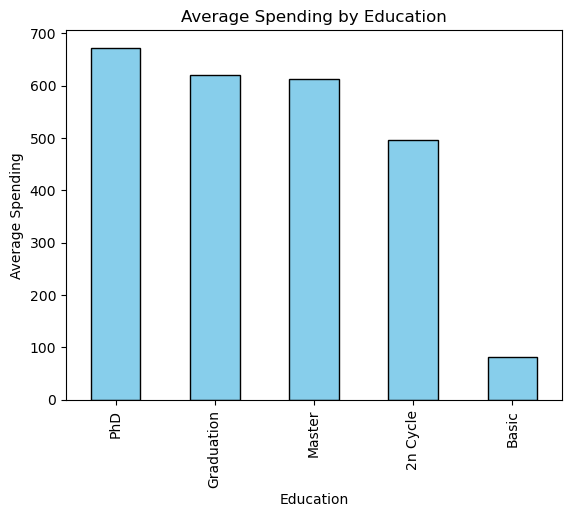

In [41]:
SbE.plot(kind='bar',color='skyblue', edgecolor='black')
plt.title('Average Spending by Education')
plt.ylabel('Average Spending')

plt.show

In [42]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Spending', 'Customer_Since', 'TotalPurchases',
       'Income_per_Child', 'Spending_per_Visit'],
      dtype='object')

In [43]:
# Creating  AcceptedAll 
df['AcceptedAll'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)
df['AcceptedAll'].value_counts()

AcceptedAll
0    1631
1     370
2     142
3      51
4      36
5      10
Name: count, dtype: int64

In [44]:
#  
df['AcceptedAll'] = df['AcceptedAll'].apply(lambda x: 1 if x > 0 else 0 )
df['AcceptedAll'].value_counts()

AcceptedAll
0    1631
1     609
Name: count, dtype: int64

In [45]:
# Average Acceptance by Marital Status (AAbMS )
AAbMS= df.groupby('Marital_Status')['AcceptedAll'].mean().sort_values(ascending=False)
AAbMS

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.350649
Alone       0.333333
Single      0.308333
Divorced    0.297414
Married     0.251157
Together    0.250000
Name: AcceptedAll, dtype: float64

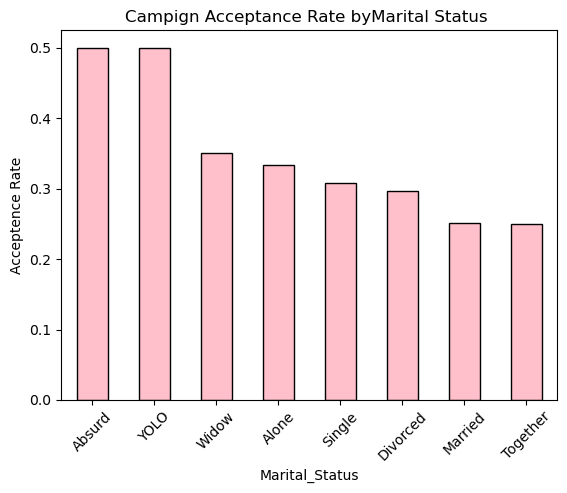

In [46]:
AAbMS.plot(kind='bar', color='pink', edgecolor='black')
plt.title('Campign Acceptance Rate byMarital Status ')
plt.ylabel('Acceptence Rate' )
plt.xticks(rotation=45)
plt.show()

In [47]:
# Age groups by incomes
bins= [18,30,40,50,60,70,80,90]
labels = ['18-29','30-39','40-49','50-59','60-69','70-79','80']

In [48]:
df['AgeGroup'] = pd.cut(df['Age'], bins=bins , labels=labels)
df['AgeGroup']

0       60-69
1       70-79
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236    70-79
2237    40-49
2238    60-69
2239    70-79
Name: AgeGroup, Length: 2240, dtype: category
Categories (7, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70-79' < '80']

In [49]:
# Average Income by Age group (AIbAG)
AIbAG = df.groupby('AgeGroup')['Income'].mean()
AIbAG

AgeGroup
18-29    46658.000000
30-39    46330.677570
40-49    49240.364452
50-59    50818.801036
60-69    56118.269807
70-79    58562.936667
80       64677.156250
Name: Income, dtype: float64

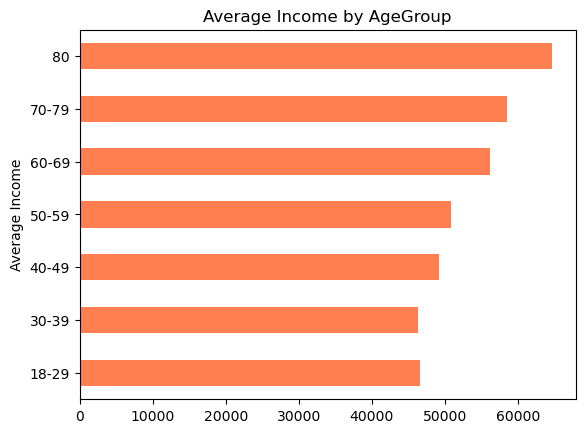

In [50]:
AIbAG.plot(kind='barh', color='coral')
plt.title('Average Income by AgeGroup')
plt.ylabel('Average Income')
plt.show()

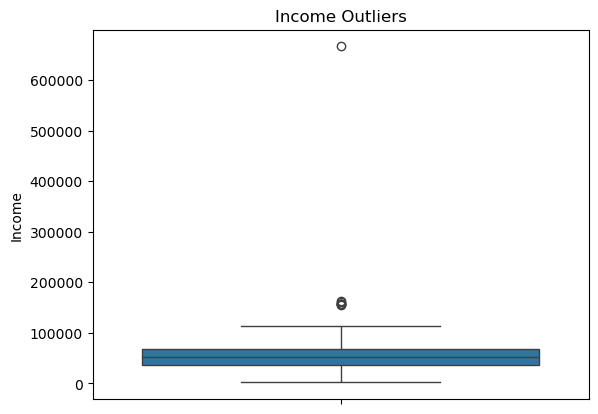

In [51]:
# Outliers 
# Outliers in Income
sns.boxplot(df['Income'])
plt.title('Income Outliers')
plt.show()


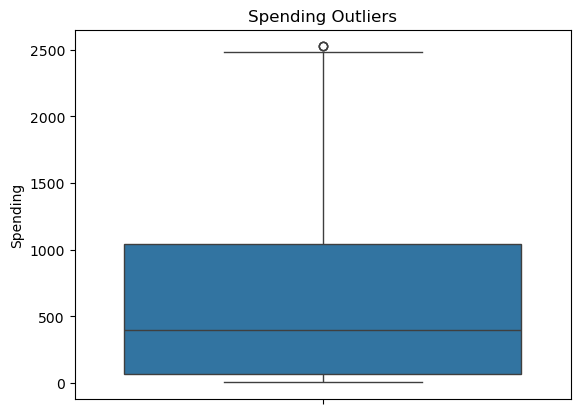

In [52]:
# 
# outliers in Spending 
sns.boxplot(df['Spending'])
plt.title('Spending Outliers')
plt.show()


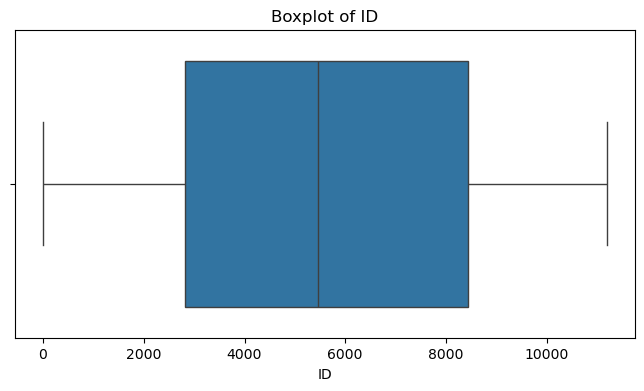

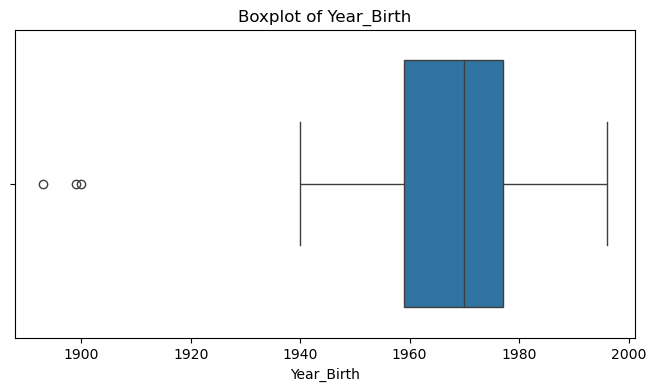

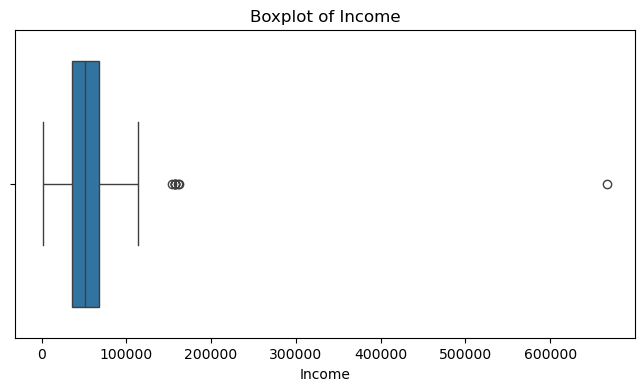

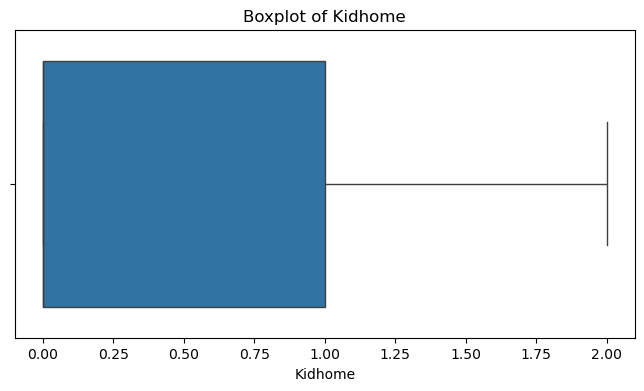

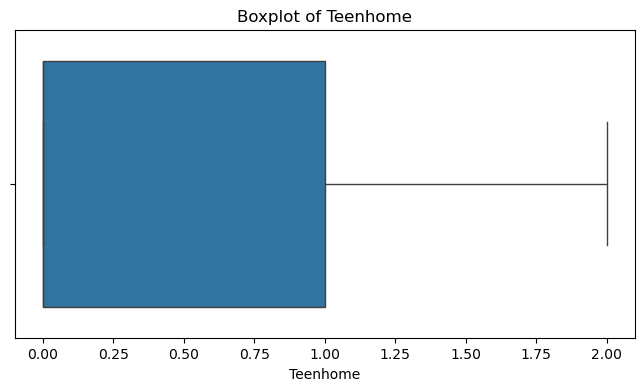

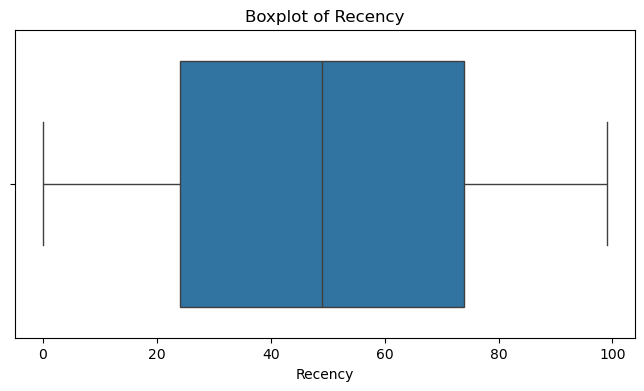

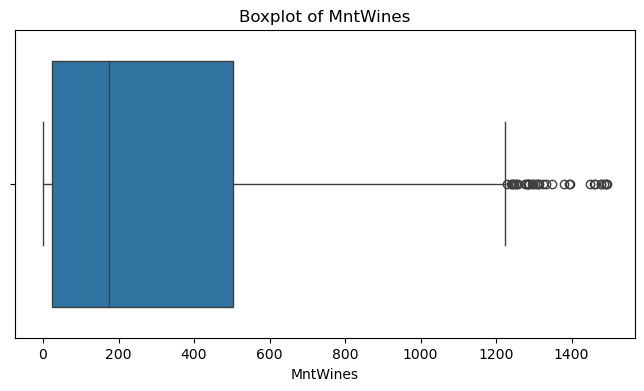

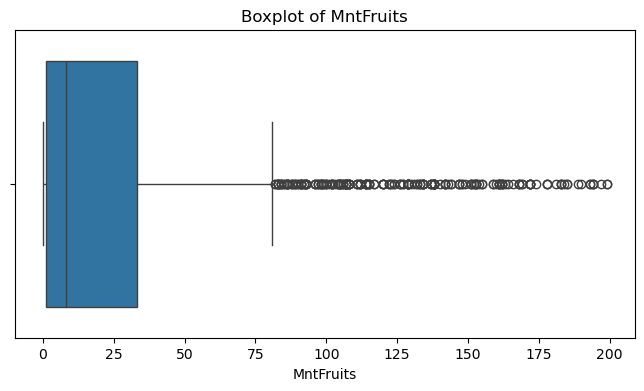

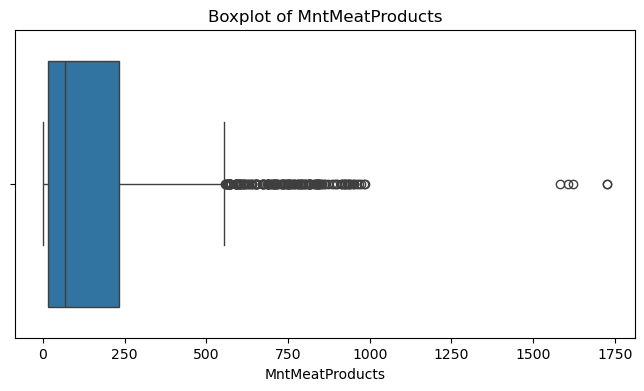

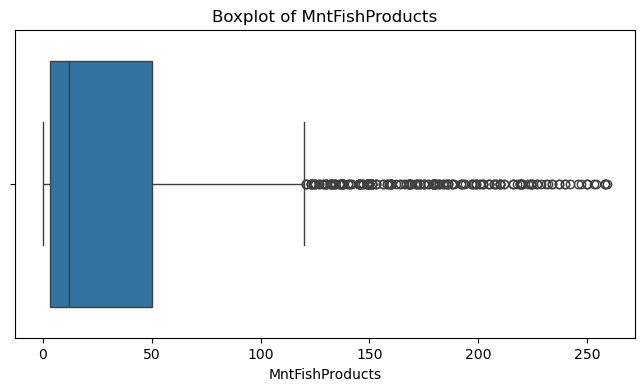

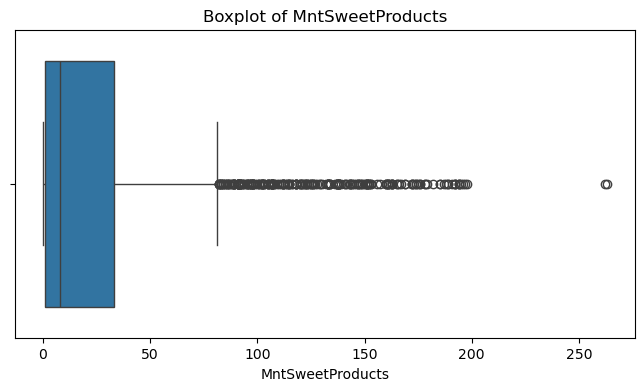

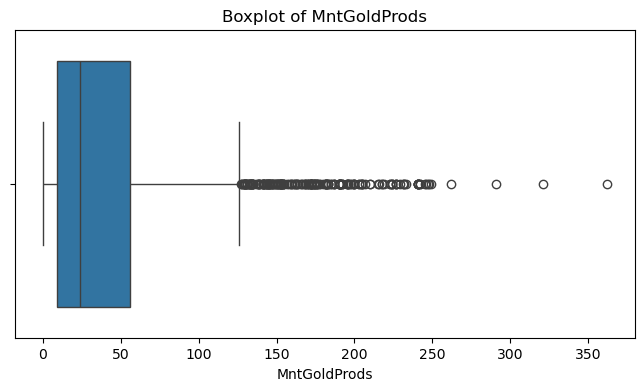

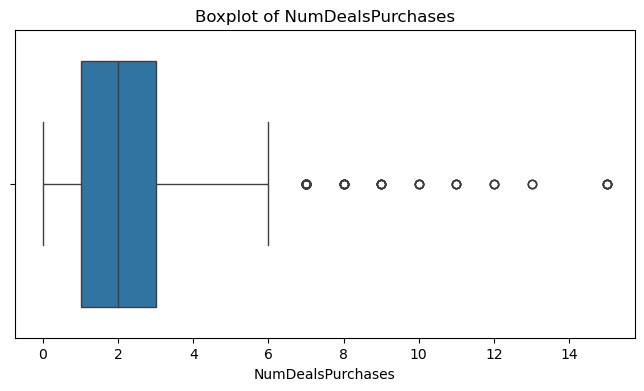

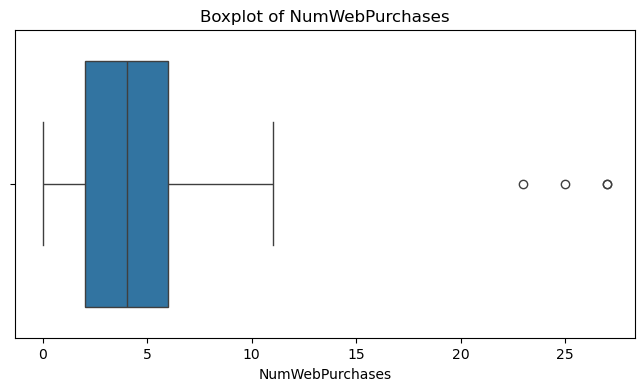

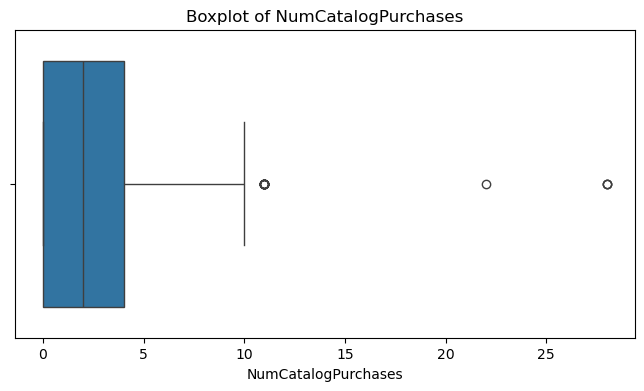

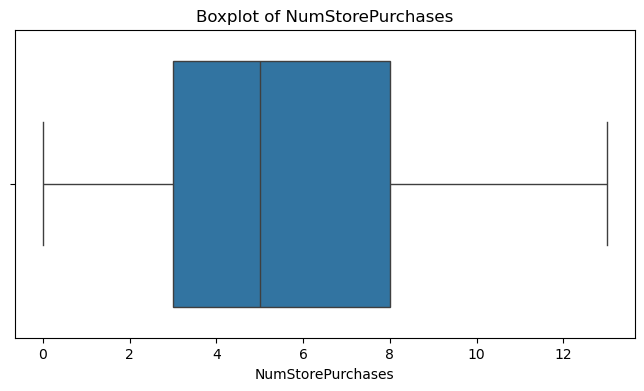

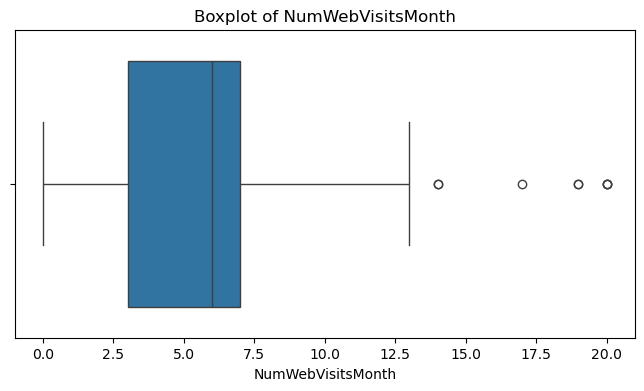

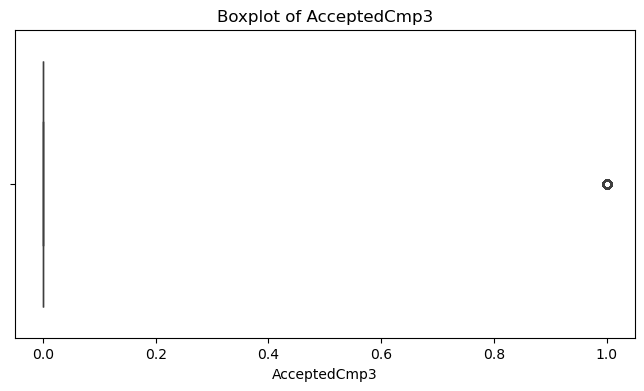

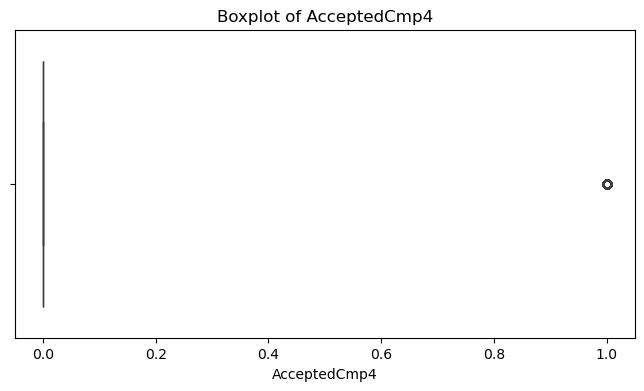

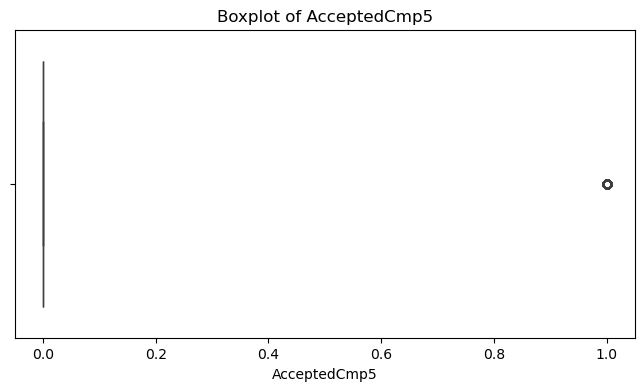

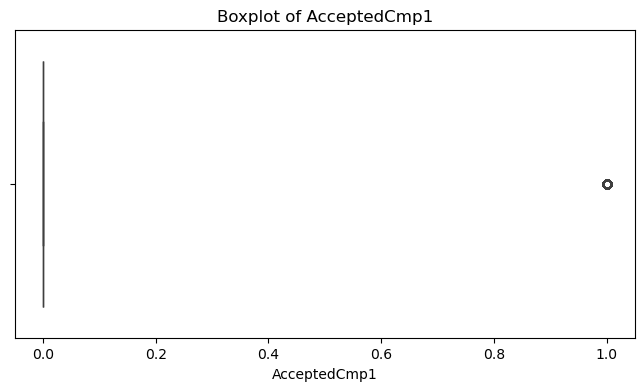

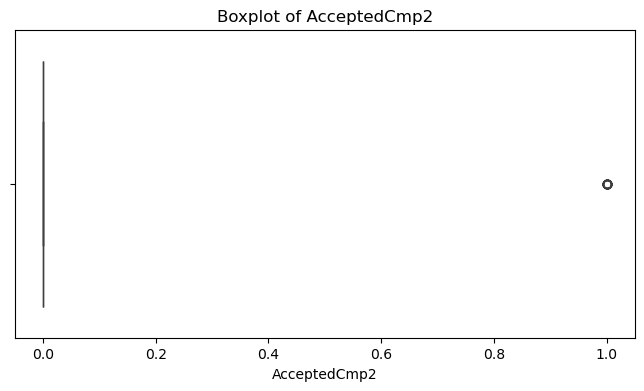

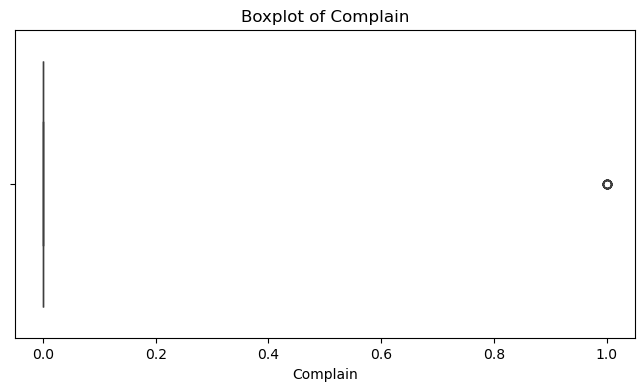

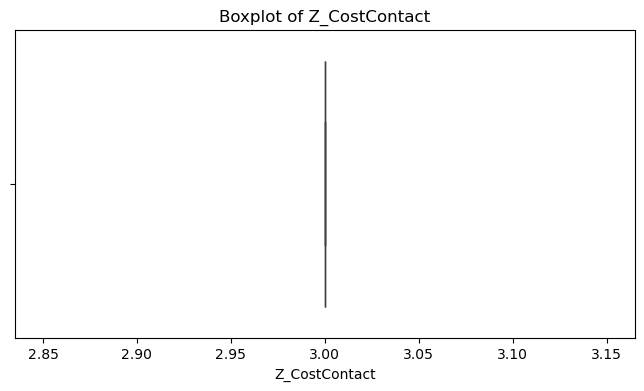

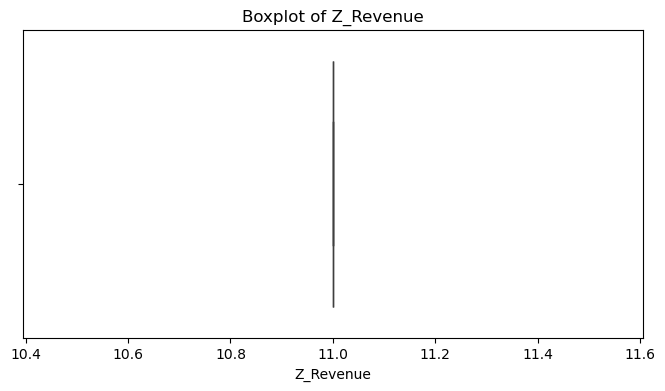

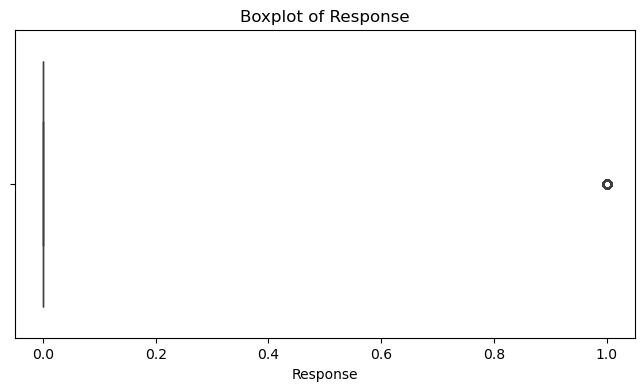

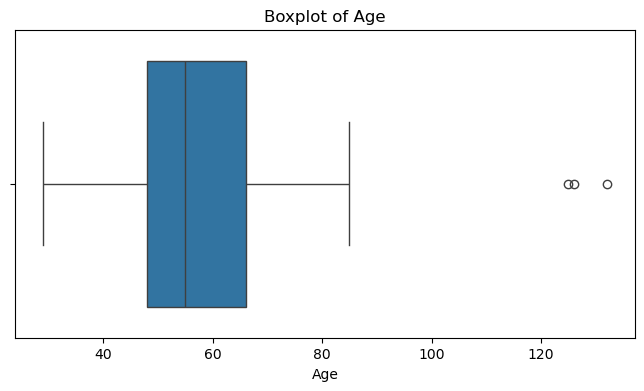

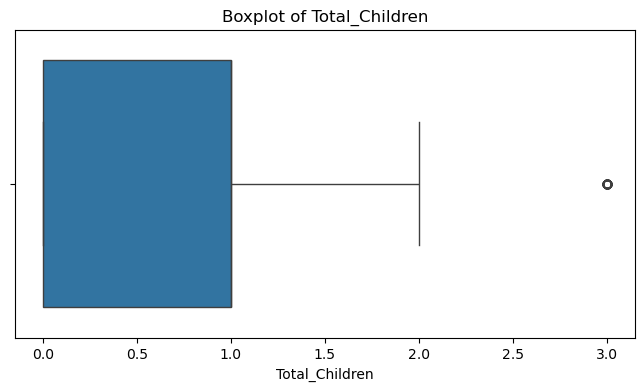

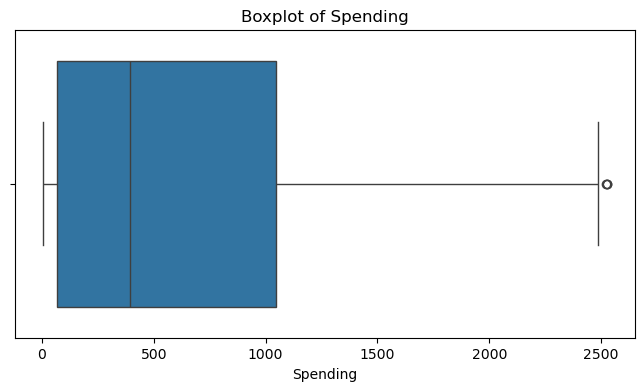

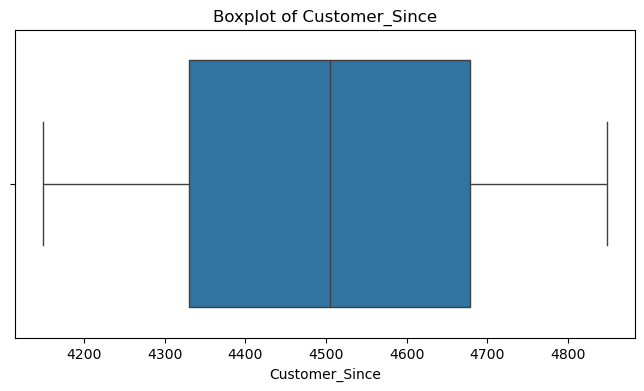

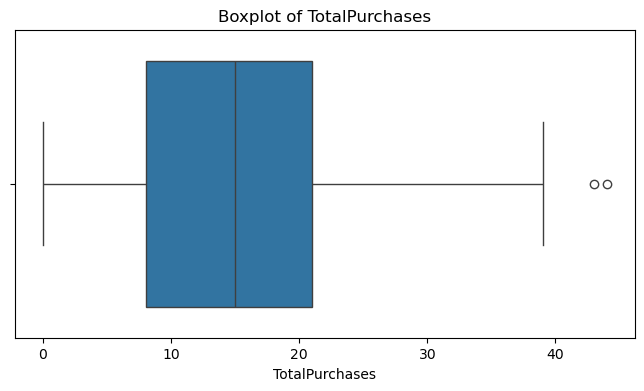

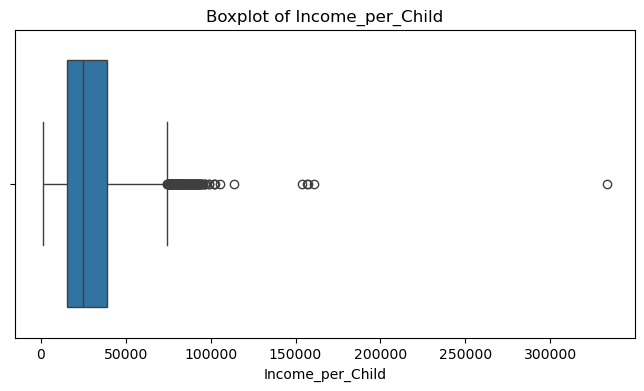

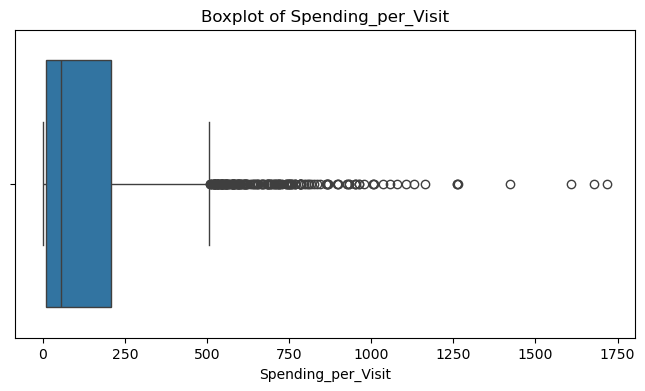

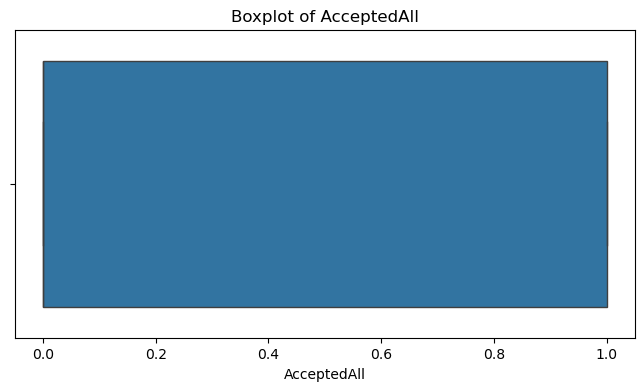

In [53]:
# Select only numeric columns (int or float)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

# Create boxplots for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [54]:
# Encoding Education and Marital Status 
 
df1 = pd.get_dummies(df, columns=['Education', 'Marital_Status'], drop_first=True)
df1

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,True,False,False,False,False,False,True,False,False,False
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,True,False,False,False,False,False,True,False,False,False
2,4141,1965,71613.0,0,0,2013-08-21,26,426,49,127,...,True,False,False,False,False,False,False,True,False,False
3,6182,1984,26646.0,1,0,2014-02-10,26,11,4,20,...,True,False,False,False,False,False,False,True,False,False
4,5324,1981,58293.0,1,0,2014-01-19,94,173,43,118,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,61223.0,0,1,2013-06-13,46,709,43,182,...,True,False,False,False,False,True,False,False,False,False
2236,4001,1946,64014.0,2,1,2014-06-10,56,406,0,30,...,False,False,True,False,False,False,False,True,False,False
2237,7270,1981,56981.0,0,0,2014-01-25,91,908,48,217,...,True,False,False,False,True,False,False,False,False,False
2238,8235,1956,69245.0,0,1,2014-01-24,8,428,30,214,...,False,True,False,False,False,False,False,True,False,False


In [55]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Age,Total_Children,Spending,Customer_Since,TotalPurchases,Income_per_Child,Spending_per_Visit,AcceptedAll,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1,68,0,1617,4812,25,58138.0,202.125000,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,71,2,27,4262,6,15448.0,4.500000,0,70-79
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,60,0,776,4461,21,71613.0,155.200000,0,50-59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,41,1,53,4288,8,13323.0,7.571429,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,44,1,422,4310,19,29146.5,70.333333,0,40-49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,58,1,1341,4530,18,30611.5,223.500000,0,50-59
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,79,3,444,4168,22,16003.5,55.500000,1,70-79
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,44,0,1241,4304,19,56981.0,177.285714,1,40-49
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,69,1,843,4305,23,34622.5,210.750000,0,60-69


In [56]:
df1.sample(10)

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
1471,4864,1977,34380.0,1,0,2013-05-02,68,72,7,58,...,True,False,False,False,False,True,False,False,False,False
1779,2681,1984,65370.0,0,0,2013-08-01,1,71,22,112,...,False,False,False,False,False,True,False,False,False,False
1691,6349,1987,61787.0,0,0,2013-07-06,71,621,73,414,...,False,True,False,False,True,False,False,False,False,False
344,8234,1973,27190.0,1,0,2013-08-15,13,1,6,7,...,False,False,False,False,False,False,False,True,False,False
748,2281,1970,33697.0,1,0,2013-09-15,34,4,3,7,...,True,False,False,False,False,False,True,False,False,False
2157,1515,1975,34176.0,0,1,2014-01-22,9,11,2,7,...,False,True,False,False,False,False,False,True,False,False
1745,9292,1952,81795.0,0,0,2012-10-26,74,324,132,693,...,True,False,False,False,False,True,False,False,False,False
1355,3834,1962,69627.0,0,1,2013-03-17,35,231,161,215,...,True,False,False,False,False,False,True,False,False,False
522,9214,1991,42691.0,0,0,2013-08-16,48,179,2,64,...,True,False,False,False,False,True,False,False,False,False
1521,8643,1971,69930.0,0,0,2013-05-26,21,252,98,827,...,True,False,False,False,False,False,False,True,False,False


In [57]:
df1.columns

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age',
       'Total_Children', 'Spending', 'Customer_Since', 'TotalPurchases',
       'Income_per_Child', 'Spending_per_Visit', 'AcceptedAll', 'AgeGroup',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='object')

In [58]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       2240 non-null   int64         
 1   Year_Birth               2240 non-null   int64         
 2   Income                   2240 non-null   float64       
 3   Kidhome                  2240 non-null   int64         
 4   Teenhome                 2240 non-null   int64         
 5   Dt_Customer              2240 non-null   datetime64[ns]
 6   Recency                  2240 non-null   int64         
 7   MntWines                 2240 non-null   int64         
 8   MntFruits                2240 non-null   int64         
 9   MntMeatProducts          2240 non-null   int64         
 10  MntFishProducts          2240 non-null   int64         
 11  MntSweetProducts         2240 non-null   int64         
 12  MntGoldProds             2240 non-

In [59]:
# Select only categorical columns
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns
categorical_cols

Index(['AgeGroup'], dtype='object')

In [60]:
# Select only numeric columns (int or float)
numeric_cols = df1.select_dtypes(include=['int64', 'float64']).columns
numeric_cols


Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response', 'Age', 'Total_Children', 'Spending',
       'Customer_Since', 'TotalPurchases', 'Income_per_Child',
       'Spending_per_Visit', 'AcceptedAll'],
      dtype='object')

In [61]:
# Feature extraction
#Feature that represents customers' demographics and behaviours

In [62]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       2240 non-null   int64         
 1   Year_Birth               2240 non-null   int64         
 2   Income                   2240 non-null   float64       
 3   Kidhome                  2240 non-null   int64         
 4   Teenhome                 2240 non-null   int64         
 5   Dt_Customer              2240 non-null   datetime64[ns]
 6   Recency                  2240 non-null   int64         
 7   MntWines                 2240 non-null   int64         
 8   MntFruits                2240 non-null   int64         
 9   MntMeatProducts          2240 non-null   int64         
 10  MntFishProducts          2240 non-null   int64         
 11  MntSweetProducts         2240 non-null   int64         
 12  MntGoldProds             2240 non-

In [63]:
df1.columns

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age',
       'Total_Children', 'Spending', 'Customer_Since', 'TotalPurchases',
       'Income_per_Child', 'Spending_per_Visit', 'AcceptedAll', 'AgeGroup',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='object')

In [200]:
# Feature selection 
features = [
    'Income', 'Age', 'Recency', 'Total_Children', 'Spending',
    'TotalPurchases', 'NumWebVisitsMonth', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
    'Income_per_Child', 'Spending_per_Visit',
    
    # Encoded Education
    'Education_Graduation', 'Education_Master', 'Education_PhD', 'Education_Basic',
    
    # Encoded Marital Status
    'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married',
    'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow',
    'Marital_Status_YOLO'
]


In [202]:
X =df1[features].copy()
X.sample(5)

,Income,Age,Recency,Total_Children,Spending,TotalPurchases,NumWebVisitsMonth,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,Education_Master,Education_PhD,Education_Basic,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
355,38643.0,47,45,2,49,7,7,2,0,3,...,False,False,False,False,False,False,True,False,False,False
1370,57338.0,50,96,1,237,12,5,4,1,5,...,False,False,False,False,False,False,True,False,False,False
1380,46390.0,70,56,1,222,10,7,4,2,3,...,True,False,False,False,True,False,False,False,False,False
1799,75774.0,44,27,1,823,21,4,7,5,8,...,False,False,False,False,False,False,False,True,False,False
1566,63972.0,61,93,1,1269,23,4,5,4,10,...,True,False,False,False,False,False,True,False,False,False


In [204]:
#Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.23569584,  0.98534473,  0.30703926, ..., -0.59109863,
        -0.18867619, -0.02989406],
       [-0.23545419,  1.23573295, -0.38366418, ..., -0.59109863,
        -0.18867619, -0.02989406],
       [ 0.77399892,  0.3176428 , -0.79808624, ...,  1.69176504,
        -0.18867619, -0.02989406],
       ...,
       [ 0.18947568, -1.01776106,  1.44669994, ..., -0.59109863,
        -0.18867619, -0.02989406],
       [ 0.67940139,  1.06880747, -1.41971934, ...,  1.69176504,
        -0.18867619, -0.02989406],
       [ 0.02520835,  1.23573295, -0.31459383, ..., -0.59109863,
        -0.18867619, -0.02989406]])

In [206]:
 # Model Selection for Clustering

In [208]:
# Kmeans clusterin
scores = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append((k, score))

best_k_kmeans = max(scores, key=lambda x: x[1])
print(f"Best K (K-Means): {best_k_kmeans}")


Best K (K-Means): (2, 0.20506107793235673)


In [209]:
# GaussianMixture
scores = []
for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append((k, score))

best_gmm = max(scores, key=lambda x: x[1])
print(f"Best K (GMM): {best_gmm}")


Best K (GMM): (2, 0.4127245218342971)


In [210]:
# DBSCAN Clustering
db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Estimated clusters (DBSCAN):", n_clusters)

if n_clusters > 1:
    print("Silhouette Score (DBSCAN):", silhouette_score(X_scaled, labels))
else:
    print("DBSCAN failed to form valid clusters.")


Estimated clusters (DBSCAN): 0
DBSCAN failed to form valid clusters.


In [212]:
# comparing 
print("\nModel Comparison:")
print(f"K-Means best silhouette: {best_k_kmeans[1]:.3f} (k={best_k_kmeans[0]})")
print(f"GMM best silhouette: {best_gmm[1]:.3f} (k={best_gmm[0]})")
print(f"DBSCAN clusters: {n_clusters}")



Model Comparison:
K-Means best silhouette: 0.205 (k=2)
GMM best silhouette: 0.413 (k=2)
DBSCAN clusters: 0


In [214]:
# Appling Kmeans clustering

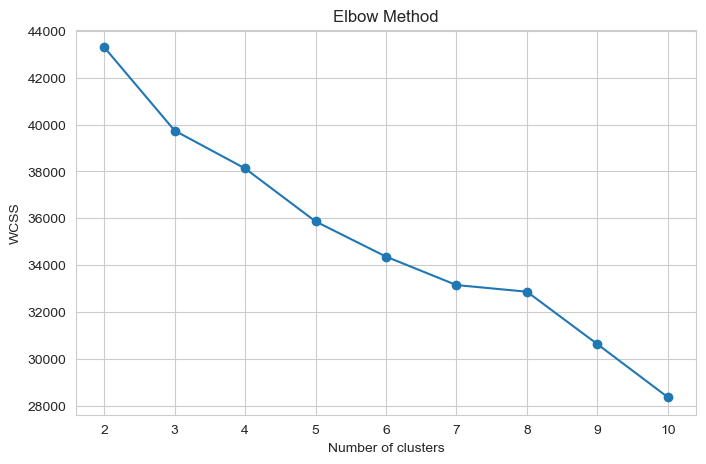

In [215]:
# WCSS (Elbow Method)
wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


In [216]:
# Silhouette Score
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.3f}")


k=2, Silhouette Score=0.205
k=3, Silhouette Score=0.160
k=4, Silhouette Score=0.136
k=5, Silhouette Score=0.138
k=6, Silhouette Score=0.147
k=7, Silhouette Score=0.145
k=8, Silhouette Score=0.126
k=9, Silhouette Score=0.128


In [217]:
# K-Means with chosen k = 3
kmeans = KMeans(n_clusters=3, random_state=42)
df1['Clusters'] = kmeans.fit_predict(X_scaled)


In [218]:
# Analyze clusters
cluster_summary = df1.groupby('Clusters')[features].mean().round(2)
print(cluster_summary)

            Income    Age  Recency  Total_Children  Spending  TotalPurchases  \
Clusters                                                                       
0         34827.02  53.68    49.56            1.23     96.87            7.78   
1         78940.00  56.64    49.41            0.07   1401.83           20.26   
2         58754.01  59.53    48.24            1.17    785.35           21.35   

          NumWebVisitsMonth  NumWebPurchases  NumCatalogPurchases  \
Clusters                                                            
0                      6.43             2.07                 0.55   
1                      2.43             4.84                 6.15   
2                      5.73             6.48                 3.27   

          NumStorePurchases  ...  Education_Master  Education_PhD  \
Clusters                     ...                                    
0                      3.19  ...              0.16           0.18   
1                      8.18  ...              

In [219]:
# PCA 
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)
df1['PCA1'],df1['PCA2'] = pca_data[:,0],pca_data[:,1]
pca_data

array([[ 2.70065767,  0.45877716],
       [-2.29736   , -0.78962704],
       [ 2.28209639, -0.2205467 ],
       ...,
       [ 1.74787633, -0.68980151],
       [ 1.95310802,  0.92154368],
       [-1.7229819 ,  1.25571527]])

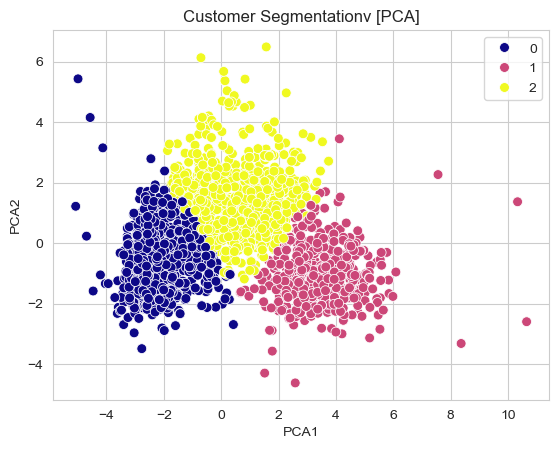

In [220]:
# Scatter Plot
# sns.scatterplot(x='PCA1', y='PCA2', hue='Clusters', data=df1, palette='Set1')
sns.scatterplot(data=df1,x='PCA1',y='PCA2',hue='Clusters',palette='plasma',s=50)
plt.title('Customer Segmentationv [PCA]')
plt.legend()
plt.show()


In [222]:
# kmeans on PCA data 
kmeans = KMeans(n_clusters=3, random_state=42)
km_labels = kmeans.fit_predict(pca_data)

# Convert PCA data to DataFrame 
df_pca = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
df_pca['Clusters'] = km_labels


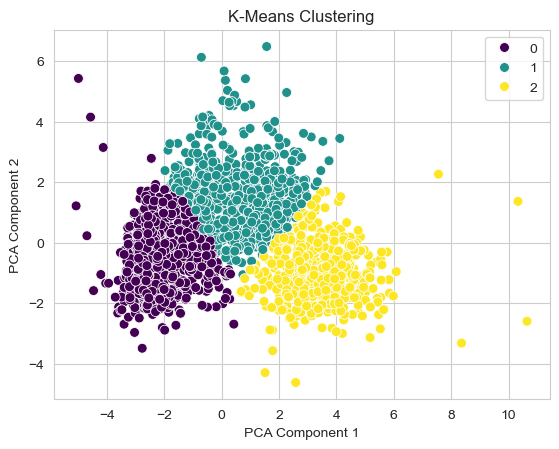

In [223]:
# scatter plot 
sns.set_style("whitegrid")
sns.scatterplot(data=df_pca,x='PCA1',y='PCA2',hue='Clusters',palette='viridis',s=50)
plt.title('K-Means Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show() 

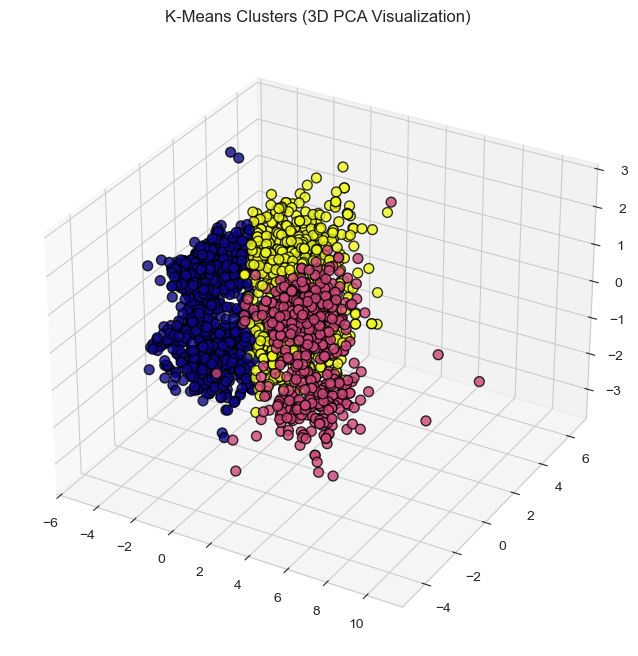

In [224]:
# 3D PCA Visualization
pca_3d = PCA(n_components=3)
pca_data_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
sub = fig.add_subplot(111, projection='3d')
sub.scatter(pca_data_3d[:, 0],pca_data_3d[:, 1],pca_data_3d[:, 2],c=df1['Clusters'],cmap='plasma',s=50,alpha=0.8,edgecolor='k')
sub.set_title('K-Means Clusters (3D PCA Visualization)')
plt.show()


In [226]:
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(kmeans, open("model.pkl", "wb"))
pickle.dump(pca, open("pca.pkl", "wb"))



In [227]:
import os
print(os.getcwd())


C:\Users\USER\Downloads\iP592CS_Deploy


In [245]:
print(scaler.feature_names_in_)


['Income' 'Age' 'Recency' 'Total_Children' 'Spending' 'TotalPurchases'
 'NumWebVisitsMonth' 'NumWebPurchases' 'NumCatalogPurchases'
 'NumStorePurchases' 'NumDealsPurchases' 'Income_per_Child'
 'Spending_per_Visit' 'Education_Graduation' 'Education_Master'
 'Education_PhD' 'Education_Basic' 'Marital_Status_Alone'
 'Marital_Status_Divorced' 'Marital_Status_Married'
 'Marital_Status_Single' 'Marital_Status_Together' 'Marital_Status_Widow'
 'Marital_Status_YOLO']
